In [1]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

In [2]:
url = 'https://aplicacoes.mds.gov.br/sagi/servicos/equipamentos?fq=tipo_equipamento:POSTO_CADASTRAMENTO&wt=csv&fl=id_equipamento,ibge,uf,cidade,nome,responsavel,telefone,endereco,numero,complemento,referencia,bairro,cep,georef_location,data_atualizacao&rows=999999999&q=*:*'

In [3]:
df = pd.read_csv(url)

In [4]:
df.head()

,id_equipamento,ibge,uf,cidade,nome,responsavel,telefone,endereco,numero,complemento,referencia,bairro,cep,georef_location,data_atualizacao
0,490243,312400,MG,ERVÁLIA,Posto de Cadastramento,NaN,NaN,Nossa Senhora Aparecida 176,176,Casa,Próximo a auto escola Millenim,Centro,36555000,"-20.84116556700237\,-42.657744884490974",2026-10-02T04:58:07.402Z
1,490259,241370,RN,SÍTIO NOVO,CADASTRO ÚNICO DE SITIO NOVO,NaN,NaN,JOSÉ FERREIRA LIMA 11,11,NaN,NaN,CENTRO,59440000,"-6.105020892490161\,-35.91006875038148",2026-10-02T04:58:07.402Z
2,490262,330280,RJ,MENDES,Cadastro Único/Bolsa Família,NaN,NaN,Professor Paulo Sérgio Nader Pereira 000,000,NaN,NaN,Centro,26700000,"-22.52687797117161\,-43.73308539390564",2026-10-02T04:58:07.402Z
3,490264,172130,TO,TUPIRATINS,POSTO DE CADASTRO UNICO TUPIRATINS,NaN,NaN,03 00,00,NaN,ANEXO I CRAS,NOVO HORIZONTE,77743000,"-8.4019462645386\,-48.133184909820564",2026-10-02T04:58:07.402Z
4,490267,313505,MG,JAÍBA,Cadastro Único Jaíba,NaN,NaN,DOIS 0,0,NaN,OBS: temos um posto de atendimento do Programa...,PROJETO JAIBA NS2,39508000,"-15.32197756557082\,-43.695030212402344",2026-10-02T04:58:07.402Z


In [5]:
df['data_atualizacao'].unique()

<ArrowStringArray>
['2026-10-02T04:58:07.402Z', '2026-10-02T04:58:07.484Z',
 '2026-10-02T04:58:07.565Z', '2026-10-02T04:58:07.659Z',
 '2026-10-02T04:58:07.751Z', '2026-10-02T04:58:07.849Z',
 '2026-10-02T04:58:07.941Z', '2026-10-02T04:58:08.033Z',
 '2026-10-02T04:58:08.123Z', '2026-10-02T04:58:08.211Z',
 '2026-10-02T04:58:07.018Z', '2026-10-02T04:58:07.096Z',
 '2026-10-02T04:58:07.166Z', '2026-10-02T04:58:07.250Z',
 '2026-10-02T04:58:07.324Z', '2026-10-02T04:58:06.620Z',
 '2026-10-02T04:58:06.705Z', '2026-10-02T04:58:06.784Z',
 '2026-10-02T04:58:06.856Z', '2026-10-02T04:58:06.932Z']
Length: 20, dtype: str

In [6]:
df = (
    df[['uf', 'cidade', 'ibge']]
    .rename(columns={
        'uf': 'sigla_uf'
    })
)

In [7]:
df.isna().sum()

sigla_uf    1
cidade      5
ibge        0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(398)

In [9]:
df.dtypes

sigla_uf      str
cidade        str
ibge        int64
dtype: object

In [10]:
df.head()

,sigla_uf,cidade,ibge
0,MG,ERVÁLIA,312400
1,RN,SÍTIO NOVO,241370
2,RJ,MENDES,330280
3,TO,TUPIRATINS,172130
4,MG,JAÍBA,313505


In [11]:
df = (
    df.groupby('sigla_uf')
    .agg({
        'ibge': 'count'
    })
    .rename(columns={
        'ibge': 'quantidade'
    })
    .sort_values('quantidade', ascending=False)
    .reset_index()
    .assign(qtde_pct = lambda x: ((x['quantidade'] / x['quantidade'].sum()) * 100).round(2))
)

In [12]:
df.head()

,sigla_uf,quantidade,qtde_pct
0,SP,482,13.55
1,BA,445,12.51
2,MG,435,12.23
3,CE,208,5.85
4,MA,207,5.82


In [13]:
df.tail()

,sigla_uf,quantidade,qtde_pct
22,MS,22,0.62
23,DF,18,0.51
24,RO,13,0.37
25,AP,12,0.34
26,RR,12,0.34


In [14]:
df['quantidade'].skew()

np.float64(1.5243816121612674)

<Axes: ylabel='Density'>

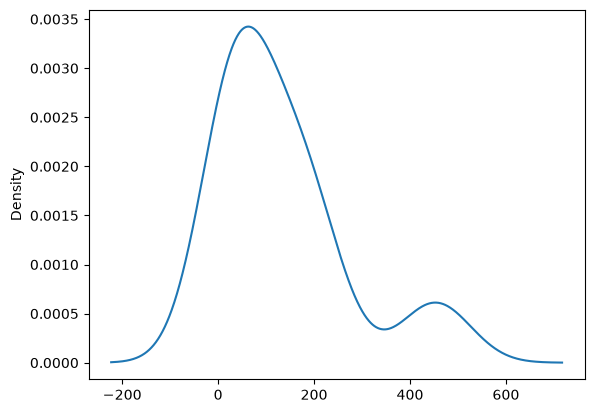

In [15]:
df['quantidade'].plot(kind='kde')

In [16]:
df['quantidade'].median()

np.float64(96.0)

In [17]:
((df['quantidade'].median() / df['quantidade'].sum()) * 100).round(2)

np.float64(2.7)

In [18]:
df.query('quantidade.median() <= quantidade').reset_index(drop=True)

,sigla_uf,quantidade,qtde_pct
0,SP,482,13.55
1,BA,445,12.51
2,MG,435,12.23
3,CE,208,5.85
4,MA,207,5.82
5,PE,204,5.74
6,PB,195,5.48
7,RS,184,5.17
8,SC,171,4.81
9,RN,152,4.27


In [19]:
df.query('quantidade.median() >= quantidade')['sigla_uf'].count()

np.int64(14)

In [20]:
gdf_ufs = (
    gpd.read_file('../../compartilhado/BR_UF_2025')
        .drop(columns=['CD_UF', 'CD_REGIAO', 'AREA_KM2', 'SIGLA_RG'])
        .rename(columns={
            'NM_UF': 'uf',
            'SIGLA_UF': 'sigla_uf',
            'NM_REGIAO': 'regiao',
        })
)

In [21]:
gdf_ufs.head()

,uf,sigla_uf,regiao,geometry
0,Rio Grande do Sul,RS,Sul,"MULTIPOLYGON (((-53.52154 -33.25881, -53.51825..."
1,São Paulo,SP,Sudeste,"MULTIPOLYGON (((-48.03575 -25.35712, -48.03607..."
2,Espírito Santo,ES,Sudeste,"MULTIPOLYGON (((-40.88385 -21.16198, -40.88384..."
3,Rio de Janeiro,RJ,Sudeste,"MULTIPOLYGON (((-44.72025 -23.35934, -44.72029..."
4,Paraná,PR,Sul,"MULTIPOLYGON (((-48.40723 -25.84254, -48.40732..."


In [22]:
(
    gdf_ufs.merge(
        df, 
        on='sigla_uf'
    ).head()
)

,uf,sigla_uf,regiao,geometry,quantidade,qtde_pct
0,Rio Grande do Sul,RS,Sul,"MULTIPOLYGON (((-53.52154 -33.25881, -53.51825...",184,5.17
1,São Paulo,SP,Sudeste,"MULTIPOLYGON (((-48.03575 -25.35712, -48.03607...",482,13.55
2,Espírito Santo,ES,Sudeste,"MULTIPOLYGON (((-40.88385 -21.16198, -40.88384...",38,1.07
3,Rio de Janeiro,RJ,Sudeste,"MULTIPOLYGON (((-44.72025 -23.35934, -44.72029...",79,2.22
4,Paraná,PR,Sul,"MULTIPOLYGON (((-48.40723 -25.84254, -48.40732...",96,2.70


In [23]:
(
    gdf_ufs.merge(
        df, 
        on='sigla_uf'
    )
    .groupby('regiao')
    .agg({
        'quantidade': 'sum'
    })
    .sort_values('quantidade', ascending=False)
    .reset_index()
    .assign(qtde_pct = lambda x: ((x['quantidade'] / x['quantidade'].sum()) * 100).round(2))
)

,regiao,quantidade,qtde_pct
0,Nordeste,1587,44.63
1,Sudeste,1034,29.08
2,Sul,451,12.68
3,Norte,300,8.44
4,Centro-oeste,184,5.17


<Axes: ylabel='Density'>

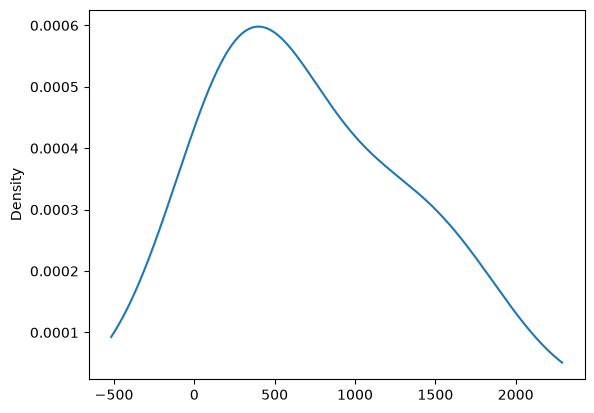

In [24]:
(
    gdf_ufs.merge(
        df, 
        on='sigla_uf'
    )
    .groupby('regiao')
    .agg({
        'quantidade': 'sum'
    })['quantidade']
    .plot(kind='kde')
)

In [25]:
(
    gdf_ufs.merge(
        df, 
        on='sigla_uf'
    )
    .groupby('regiao')
    .agg({
        'quantidade': 'sum'
    })['quantidade']
    .skew()
)


np.float64(0.9636994340488907)

In [26]:
(
    gdf_ufs.merge(
        df, 
        on='sigla_uf'
    )
    .groupby('regiao')
    .agg({
        'quantidade': 'sum'
    })
    .query('quantidade.median() <= quantidade')
)

,quantidade
regiao,
Nordeste,1587
Sudeste,1034
Sul,451


In [27]:
(
    gdf_ufs.merge(
        df, 
        on='sigla_uf'
    )
    .groupby('regiao')
    .agg({
        'quantidade': 'sum'
    })['quantidade']
    .median()
)

np.float64(451.0)

In [28]:
(
    gdf_ufs.merge(
        df, 
        on='sigla_uf'
    ).to_file('qtde_postos_cadunico.gpkg', driver='GPKG')
)